In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('data/churn.csv')
print(df.shape)                    # Should be around (36992, 23)
print(df.columns.tolist())
print(df.head())
print(df.info())
print(df.describe())

(36992, 23)
['age', 'gender', 'security_no', 'region_category', 'membership_category', 'joining_date', 'joined_through_referral', 'referral_id', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'last_visit_time', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']
   age gender security_no region_category  membership_category joining_date  \
0   18      F     XW0DQ7H         Village  Platinum Membership   17-08-2017   
1   32      F     5K0N3X1            City   Premium Membership   28-08-2017   
2   44      F     1F2TCL3            Town        No Membership   11-11-2016   
3   37      M     VJGJ33N            City        No Membership   29-10-2016   
4   31      F     SVZXCWB            City        No Membership   12-09-2017   

  joined_through_referral referral_id     preferred

In [4]:
df.replace(['?', 'Error', 'null', 'xxxxx', -999], np.nan, inplace=True)

numeric_cols = ['age', 'days_since_last_login', 'avg_time_spent', 
                'avg_transaction_value', 'points_in_wallet', 'churn_risk_score']

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['points_in_wallet', 'avg_time_spent', 'avg_transaction_value', 'age']:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

cat_cols = ['gender', 'region_category', 'membership_category', 'joined_through_referral', 
            'preferred_offer_types', 'medium_of_operation', 'internet_option', 
            'used_special_discount', 'offer_application_preference', 'past_complaint', 
            'complaint_status', 'feedback']

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

columns_to_drop = ['security_no', 'referral_id', 'last_visit_time', 
                   'joining_date', 'avg_frequency_login_days', 'customer_id']

existing_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=existing_to_drop)

# FINAL CHECK
print("\nShape after cleaning:", df.shape)
print("Columns after cleaning:", df.columns.tolist())
print("\nMissing values remaining:\n", df.isnull().sum())

# Optional: Save cleaned data
df.to_csv('data/cleaned_customer_churn.csv', index=False)
print("Cleaned dataset saved as 'cleaned_customer_churn.csv'")


Shape after cleaning: (36992, 18)
Columns after cleaning: ['age', 'gender', 'region_category', 'membership_category', 'joined_through_referral', 'preferred_offer_types', 'medium_of_operation', 'internet_option', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'used_special_discount', 'offer_application_preference', 'past_complaint', 'complaint_status', 'feedback', 'churn_risk_score']

Missing values remaining:
 age                                0
gender                             0
region_category                    0
membership_category                0
joined_through_referral            0
preferred_offer_types              0
medium_of_operation                0
internet_option                    0
days_since_last_login           1999
avg_time_spent                     0
avg_transaction_value              0
points_in_wallet                   0
used_special_discount              0
offer_application_preference       0
past_complaint            

churn_risk_score
1    0.540982
0    0.459018
Name: proportion, dtype: float64


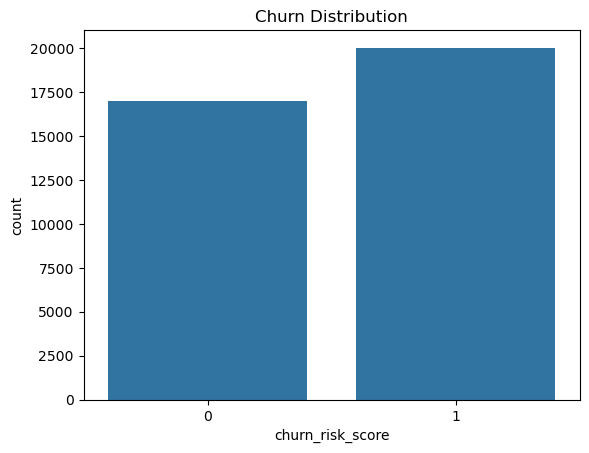

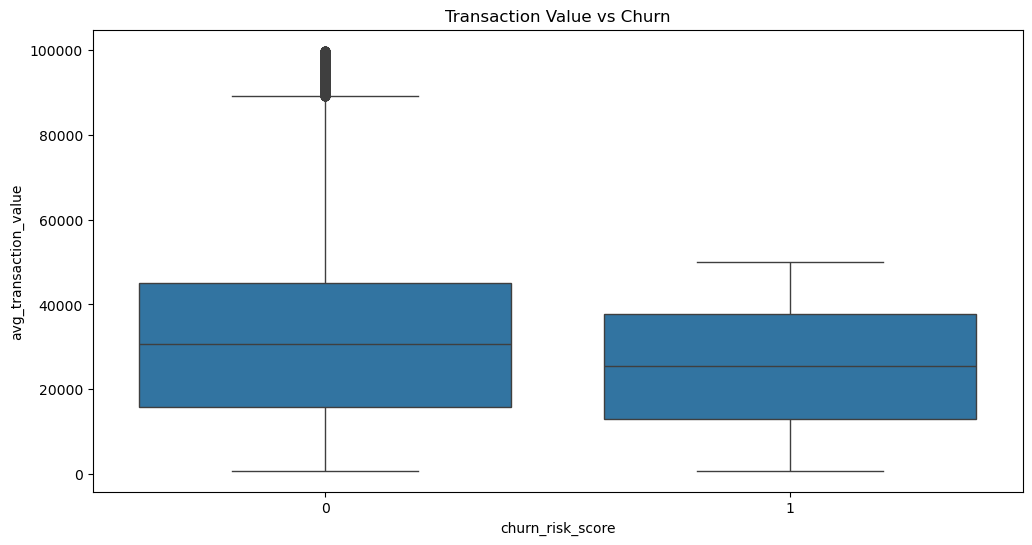

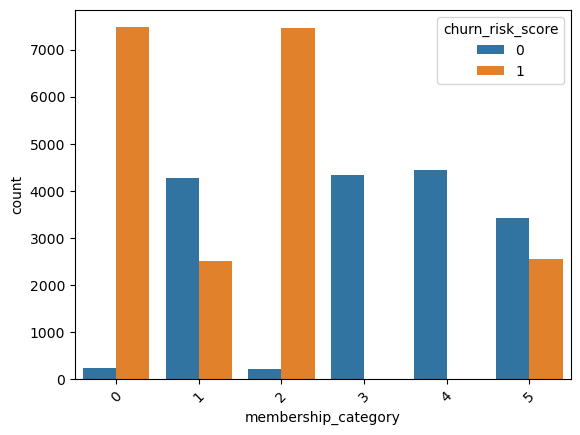

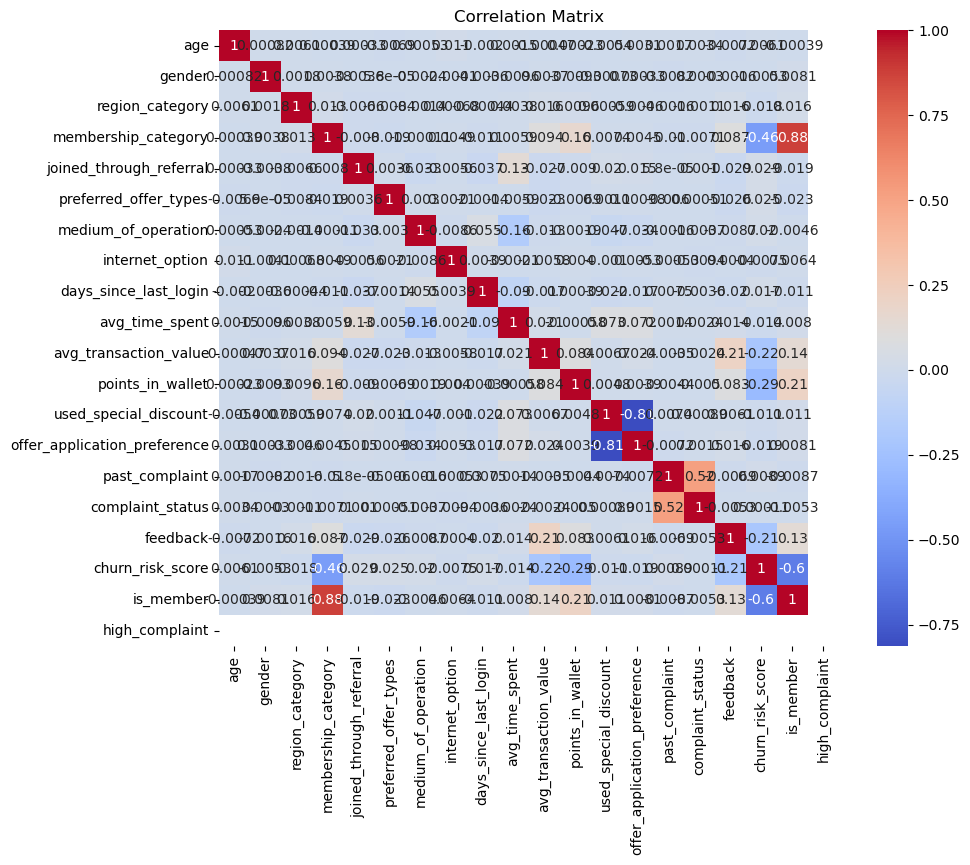

In [9]:
# Churn Rate
print(df['churn_risk_score'].value_counts(normalize=True))

sns.countplot(x='churn_risk_score', data=df)
plt.title('Churn Distribution')
plt.savefig('Insights/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Insights Visuals
plt.figure(figsize=(12, 6))
sns.boxplot(x='churn_risk_score', y='avg_transaction_value', data=df)
plt.title('Transaction Value vs Churn')
plt.savefig('Insights/TransactionValue_vs_Churn.png', dpi=300, bbox_inches='tight')
plt.show()

# Membership Category
sns.countplot(x='membership_category', hue='churn_risk_score', data=df)
plt.xticks(rotation=45)
plt.savefig('Insights/membership_category.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap (numeric features)
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.savefig('Insights/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Create new features (optional but good for resume)
df['is_member'] = df['membership_category'].apply(lambda x: 1 if x > 2 else 0)  # Adjust based on encoding
df['high_complaint'] = df['past_complaint'].map({'Yes':1, 'No':0})

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df.drop('churn_risk_score', axis=1)
y = df['churn_risk_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9268820110825787
Precision: 0.9229647630619684
Recall: 0.9443063152660368
F1 Score: 0.9335135799434681

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92      3377
           1       0.92      0.94      0.93      4022

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399


Confusion Matrix:
 [[3060  317]
 [ 224 3798]]


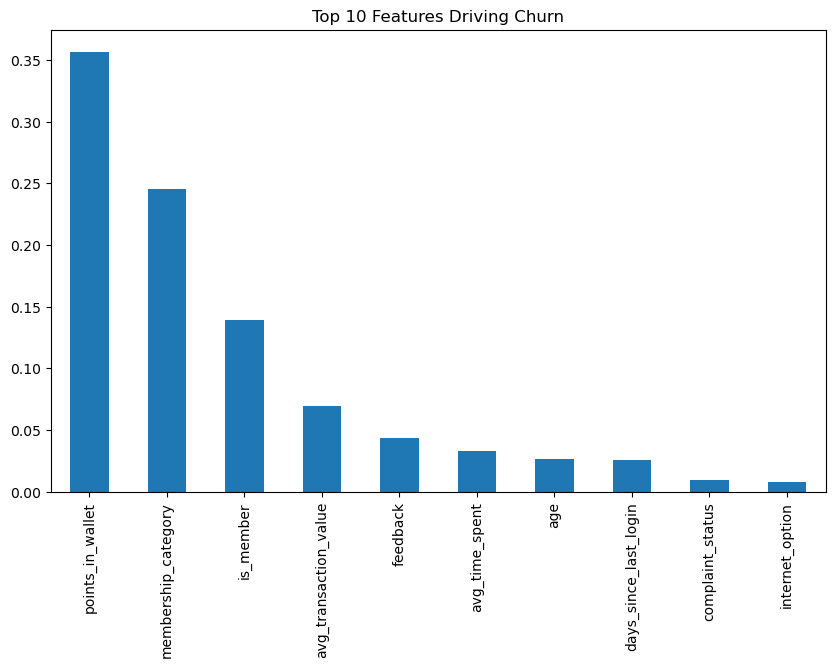

In [8]:
# Feature Importance
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importance.head(10).plot(kind='bar')
plt.title('Top 10 Features Driving Churn')
plt.savefig('Insights/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()